In [1]:
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=600, centers = [[0,0],[5,5],[0,6]], cluster_std=[0.4,1.2,0.6], random_state=42)


In [2]:
import pandas as pd

data = pd.DataFrame(X)
data['y'] = y_true

In [3]:
data.shape

(600, 3)

In [4]:
data.head

<bound method NDFrame.head of             0         1  y
0    0.089637  0.005037  0
1   -0.011783  6.331494  2
2   -0.327288  0.836955  0
3    0.471480  6.255275  2
4    4.701243  6.165885  1
..        ...       ... ..
595  0.857578  0.253568  0
596  0.045407  0.264852  0
597  1.442049  5.965429  2
598  3.382177  5.891917  1
599  3.892120  3.377978  1

[600 rows x 3 columns]>

In [5]:
data.describe()

,0,1,y
count,600.000000,600.000000,600.000000
mean,1.683100,3.677948,1.000000
std,2.431304,2.751538,0.817178
min,-1.499643,-0.795028,0.000000
25%,-0.088248,0.262105,0.000000
50%,0.362289,4.857666,1.000000
75%,4.171460,5.977088,2.000000
max,8.694657,8.158858,2.000000


In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.isnull().sum()

0    0
1    0
y    0
dtype: int64

In [9]:
X = data.drop('y', axis=1)
Y = data['y']

print(X.shape)
print(Y.shape)
print(Y.value_counts())

(600, 2)
(600,)
y
0    200
2    200
1    200
Name: count, dtype: int64


In [10]:
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

KMeans Clustering Silhouette Score:  0.751502613992254
KMeans Clustering ADJUSTED RAND SCORE:  0.9801350059845216
KMeans Clustering NORMALIZED MUTUAL INFO SCORE:  0.9701911554558436


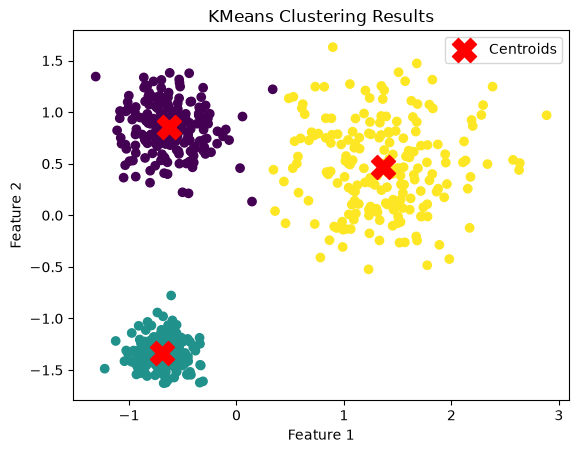

In [ ]:
# Import Evaluation Martix
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# KMeans Clustering
from sklearn.cluster import KMeans

KMeans_Model = KMeans(n_clusters=3, random_state=42, n_init=10)
KMeans_Prediction = KMeans_Model.fit_predict(X_scaled)

print("KMeans Clustering Silhouette Score: ", silhouette_score(X_scaled, KMeans_Prediction))
print("KMeans Clustering ADJUSTED RAND SCORE: ", adjusted_rand_score(Y, KMeans_Prediction))
print("KMeans Clustering NORMALIZED MUTUAL INFO SCORE: ", normalized_mutual_info_score(y_true, KMeans_Prediction))

import matplotlib.pyplot as plt
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=KMeans_Prediction, cmap='viridis')
plt.scatter(KMeans_Model.cluster_centers_[:, 0], KMeans_Model.cluster_centers_[:, 1], s=300, c='red', label='Centroids', marker='X')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KMeans Clustering Results')
plt.legend()
plt.show()

GMM Clustering Silhouette Score:  0.7494157090889104
GMM Clustering ADJUSTED RAND SCORE:  0.9949958125176231
GMM Clustering NORMALIZED MUTUAL INFO SCORE:  0.990445010867515


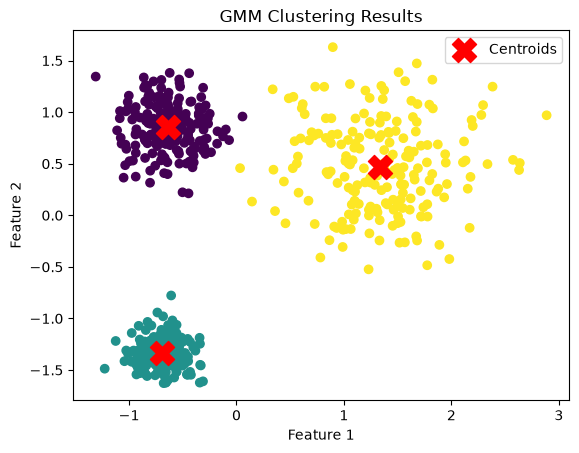

In [17]:
# GMM Clustering
from sklearn.mixture import GaussianMixture

GMM_Model = GaussianMixture(n_components=3, random_state=42)
GMM_Prediction = GMM_Model.fit_predict(X_scaled)

# ensure true labels are 1D
y_true = y_true.ravel()  # Flatten the array if it's not already 1D
print("GMM Clustering Silhouette Score: ", silhouette_score(X_scaled, GMM_Prediction))
print("GMM Clustering ADJUSTED RAND SCORE: ", adjusted_rand_score(Y, GMM_Prediction))
print("GMM Clustering NORMALIZED MUTUAL INFO SCORE: ", normalized_mutual_info_score(Y, GMM_Prediction))

import matplotlib.pyplot as plt
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=GMM_Prediction, cmap='viridis')
plt.scatter(GMM_Model.means_[:, 0], GMM_Model.means_[:, 1], s=300, c='red', label='Centroids', marker='X')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('GMM Clustering Results')
plt.legend()
plt.show()

DBSCAN Clustering Silhouette Score:  0.7116350515492958
DBSCAN Clustering ADJUSTED RAND SCORE:  0.9776721992583196
DBSCAN Clustering NORMALIZED MUTUAL INFO SCORE:  0.9621553134972989


/tmp/ipykernel_41183/1735587111.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


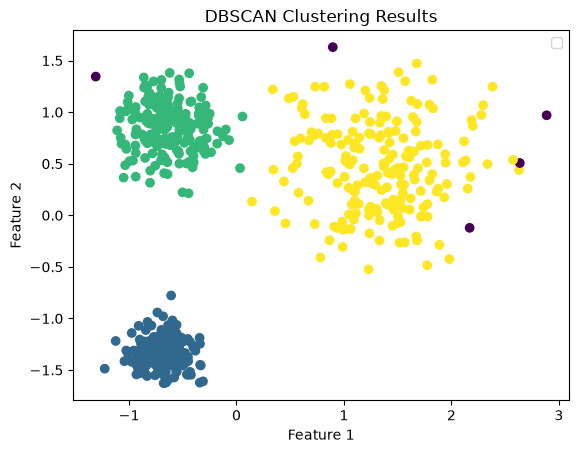

In [19]:
# DBSCAN Clustering
from sklearn.cluster import DBSCAN
DBSCAN_Model = DBSCAN(eps=0.3, min_samples=5)
DBSCAN_Prediction = DBSCAN_Model.fit_predict(X_scaled)

print("DBSCAN Clustering Silhouette Score: ", silhouette_score(X_scaled, DBSCAN_Prediction))
print("DBSCAN Clustering ADJUSTED RAND SCORE: ", adjusted_rand_score(Y, DBSCAN_Prediction))
print("DBSCAN Clustering NORMALIZED MUTUAL INFO SCORE: ", normalized_mutual_info_score(Y, DBSCAN_Prediction))


plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=DBSCAN_Prediction, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('DBSCAN Clustering Results')
plt.legend()
plt.show()


Hierarchical Clustering Silhouette Score:  0.7494157090889104
Hierarchical Clustering ADJUSTED RAND SCORE:  0.9949958125176231
Hierarchical Clustering NORMALIZED MUTUAL INFO SCORE:  0.990445010867515


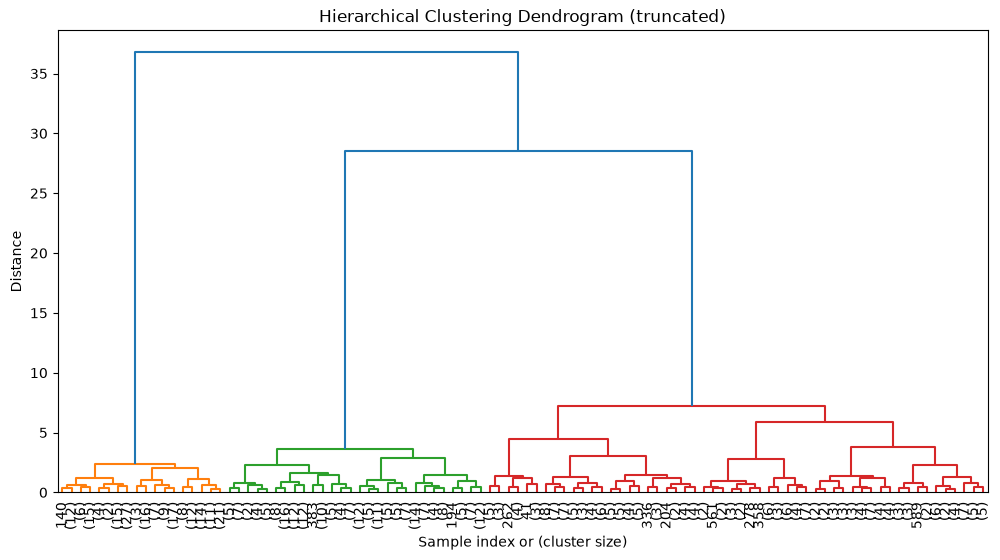

In [20]:
# Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
Hierarchical_Model = AgglomerativeClustering(n_clusters=3)
Hierarchical_Prediction = Hierarchical_Model.fit_predict(X_scaled)

print("Hierarchical Clustering Silhouette Score: ", silhouette_score(X_scaled, Hierarchical_Prediction))
print("Hierarchical Clustering ADJUSTED RAND SCORE: ", adjusted_rand_score(Y, Hierarchical_Prediction))
print("Hierarchical Clustering NORMALIZED MUTUAL INFO SCORE: ", normalized_mutual_info_score(Y, Hierarchical_Prediction))

# Plot dendrogram for Hierarchical Clustering

linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=100, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('Sample index or (cluster size)')
plt.ylabel('Distance')
plt.show()